# PART5_validate_using_breeding_lines
Validate genomic prediction model using breeding lines

In [1]:
import gc
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
sns.set()
pd.set_option('display.max_rows', 300)

from sklearn.linear_model import ElasticNet, Lasso

from modules.make_data_for_prediction import make_data
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.training_module import train_GBLUP, train_Enet
from modules.parse_pickle import get_all_accuracy, get_RILs_accuracy, get_imps
from modules.Inov_visualize import Inov, get_regions, get_hetero_regions, visualize_Inov_genotype

# make Haplotype Block genotype

In [ ]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
Inov = pd.read_csv("../data/genotype_data/Inov_2020_genotype.txt", sep="\t")

SNP_types = []
for chr_num in tqdm(range(1, 13)):
    chromosome = "chr{}".format(str(chr_num).zfill(2))
    Inov_chr = Inov[Inov.chr == chromosome]
    # read original data
    parental = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(chromosome), usecols=range(25), sep="\t")
    parental = parental.loc[parental.pos.isin(Inov_chr.pos), :]
    # extract paretal lines
    parental = parental.iloc[:, 2:23]
    # select family lines
    parental = parental.loc[:, family]
    SNP_type = ["".join(i) for i in parental.values.astype("str")]
    SNP_types.extend(SNP_type)
Inov["SNP_type"] = SNP_types

In [19]:
Haplotype_block = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
haplotype_blocks = []
for SNP_type in tqdm(Inov.SNP_type.unique()):
    Inov_SNP_type = Inov[Inov["SNP_type"] == SNP_type]
    HB_SNP_type = Haplotype_block[Haplotype_block["SNP_type"] == SNP_type]
    for each_chr in Inov_SNP_type.chr.unique():
        Inov_SNP_type_chr = Inov_SNP_type[Inov_SNP_type["chr"] == each_chr]
        HB_SNP_type_chr = HB_SNP_type[HB_SNP_type["chr"] == each_chr]
        for each_region in HB_SNP_type_chr.pos.values:
            each_region = each_region.split("_")
            if len(each_region) > 1:
                start = int(each_region[0])
                end = int(each_region[1])
                mode_value = Inov_SNP_type_chr[(Inov_SNP_type_chr["pos"] >= start) & (Inov_SNP_type_chr["pos"] <= end)].mode().values[0]
                mode_value = mode_value[2:-1]
                haplotype_block = [each_chr, "{}_{}".format(start, end), SNP_type]
                haplotype_block.extend(list(mode_value))
                haplotype_blocks.append(haplotype_block)
            else:
                mode_value = Inov_SNP_type_chr[Inov_SNP_type_chr["pos"] == int(each_region[0])].values[0]
                mode_value = mode_value[2:-1]
                haplotype_block = [each_chr, "{}".format(each_region[0]), SNP_type]
                haplotype_block.extend(list(mode_value))
                haplotype_blocks.append(haplotype_block)
Inov_haplotype_blocks = pd.DataFrame(haplotype_blocks)
Inov_columns = ["chr", "pos", "SNP_type"]
Inov_columns.extend(list(Inov.columns[2:-1]))
Inov_haplotype_blocks.columns = Inov_columns
Inov_haplotype_blocks.head()

100%|██████████| 17146/17146 [26:26<00:00, 10.81it/s] 


,chr,pos,SNP_type,Hitomebore,SHit1_8,Hit_NIL_PHS,Hit_NIL_PHSsd1,Hit_NIL_sd1,Hit_NIL_TB1,Inov_01,...,Inov_12,Inov_13,Inov_14,Inov_15,Inov_16,Inov_17,Inov_18,Inov_19,Inov_20,Inov_21
0,chr01,173888_227116,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr01,1133553_1218575,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,chr01,2169929_2346570,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr01,2363020_2397634,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr01,6282484_6282489,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [20]:
final_Inov_haplotype_blocks = pd.DataFrame()
for i in tqdm(range(Haplotype_block.shape[0])):
    tmp_chr = Haplotype_block.iloc[i, 0]
    tmp_pos = Haplotype_block.iloc[i, 1]
    tmp_SNP_type = Haplotype_block.iloc[i, 2]
    tmp = Inov_haplotype_blocks[(Inov_haplotype_blocks["chr"] == tmp_chr) & (Inov_haplotype_blocks["pos"] == tmp_pos)]
    if tmp.shape[0] > 0:
        final_Inov_haplotype_blocks = pd.concat([final_Inov_haplotype_blocks, tmp])
    else:
        tmp = [tmp_chr, tmp_pos, tmp_SNP_type]
        tmp.extend(np.repeat(np.nan, Inov_haplotype_blocks.shape[1]-3))
        tmp = pd.DataFrame(tmp).T
        tmp.columns = Inov_haplotype_blocks.columns
        final_Inov_haplotype_blocks = pd.concat([final_Inov_haplotype_blocks, tmp])
final_Inov_haplotype_blocks.to_csv("../data/PART6_validate_with_Inov_lines/Haplotype_Inov_LD90.csv", index=None)
final_Inov_haplotype_blocks

100%|██████████| 57085/57085 [06:04<00:00, 156.65it/s]


,chr,pos,SNP_type,Hitomebore,SHit1_8,Hit_NIL_PHS,Hit_NIL_PHSsd1,Hit_NIL_sd1,Hit_NIL_TB1,Inov_01,...,Inov_12,Inov_13,Inov_14,Inov_15,Inov_16,Inov_17,Inov_18,Inov_19,Inov_20,Inov_21
0,chr01,173888_227116,20222222000000020000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
251,chr01,173923_183480,02000000002220200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
259,chr01,173947_187526,00000000000200000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
798,chr01,174027_687798,00000200000000000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1242,chr01,174372_580275,00000000000000002000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5383,chr12,27474449,22222222002020220000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7077,chr12,27510884,02000000000220200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45862,chr12,27511772,00000000000002000200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44699,chr12,27526131,00000000020002000200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Visualize genotype of breeding line

In [2]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
Inov_genotype = pd.read_csv("../data/PART6_validate_with_Inov_lines/Haplotype_Inov_LD90.csv")
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
Inov_genotype.SNP_type = genotype.SNP_type

del genotype
gc.collect()

chr_ends = []
for i, each_chr in enumerate(Inov_genotype.chr.unique()):
    chr_genotype = Inov_genotype[Inov_genotype["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
    chr_ends.append(end)

pos_array = Inov_genotype.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
Inov_genotype["start"] = pos[:, 0]
Inov_genotype["end"] = pos[:, 1]

SNP_types = pd.DataFrame([list(str(i).zfill(len(family))) for i in Inov_genotype.SNP_type])
SNP_types.columns = [i[:3] for i in family]
SNP_types.index = Inov_genotype.index.values
Inov_genotype = pd.concat([Inov_genotype, SNP_types.loc[:, ['N05', 'N11', 'N12', 'N14', 'N18']]], axis=1)
Inov_genotype = Inov_genotype.loc[(Inov_genotype.loc[:, ['N05', 'N11', 'N12', 'N14', 'N18']] != "0").sum(axis=1) != 0, :]

Inov_01


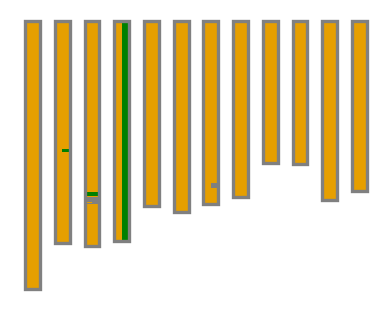

Inov_02


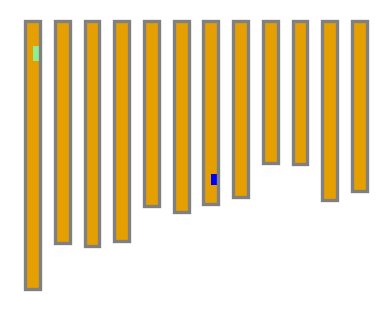

Inov_03


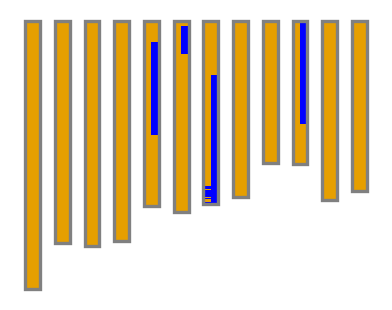

Inov_04


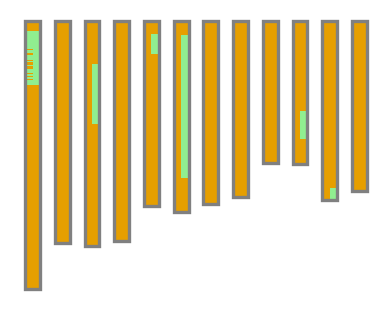

Inov_05


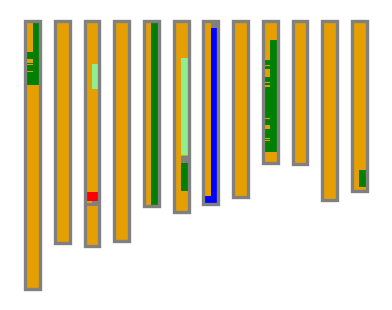

Inov_06


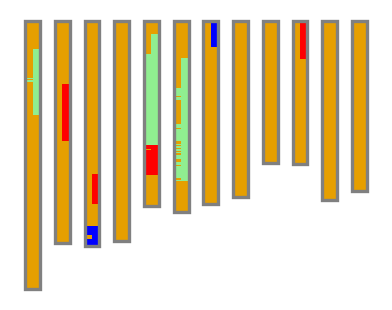

Inov_07


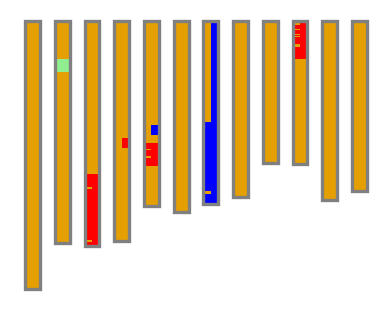

Inov_08


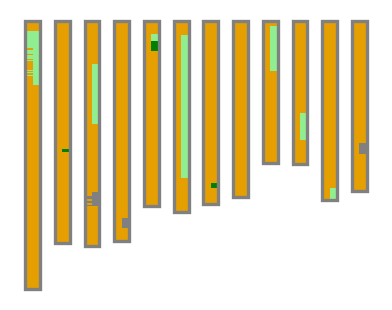

Inov_09


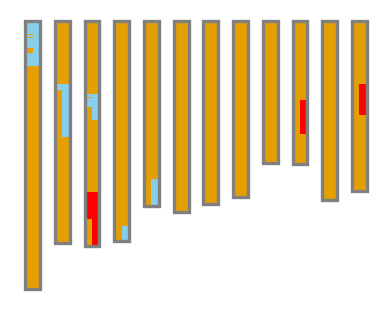

Inov_10


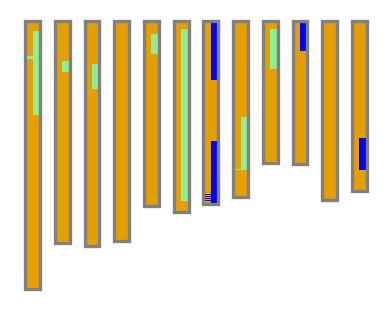

Inov_11


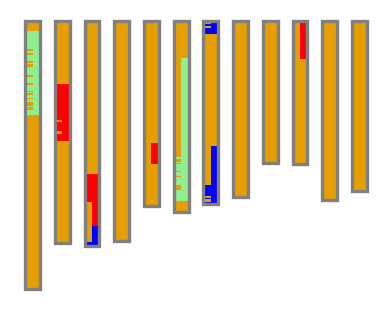

Inov_12


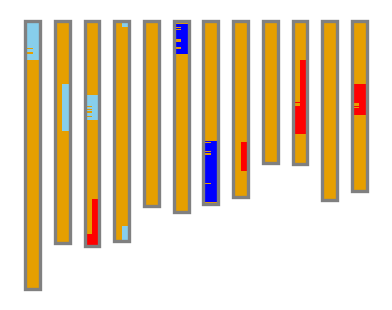

Inov_13


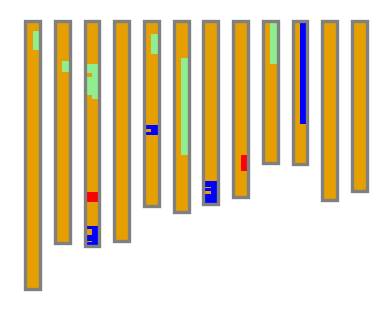

Inov_14


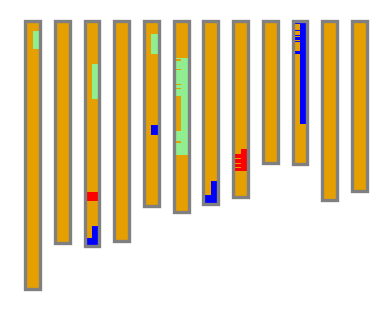

Inov_15


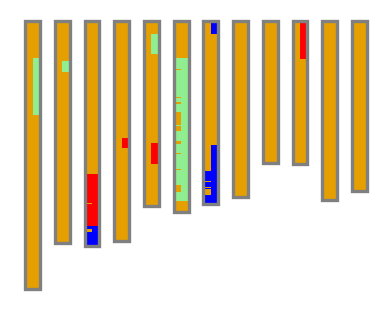

Inov_16


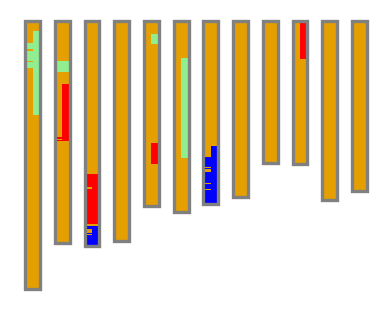

Inov_17


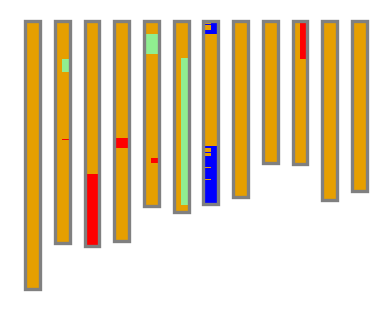

Inov_18


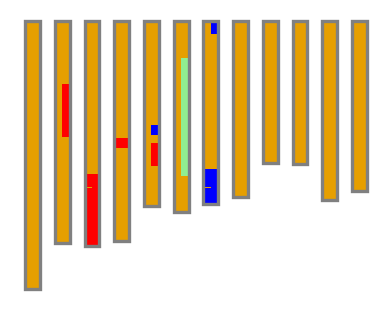

Inov_19


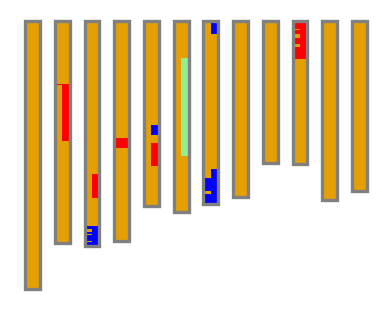

Inov_20


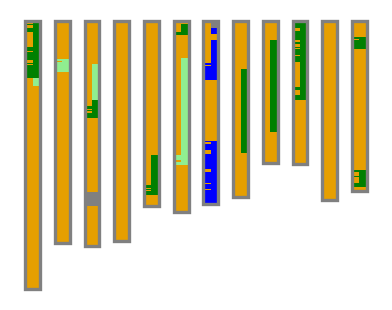

Inov_21


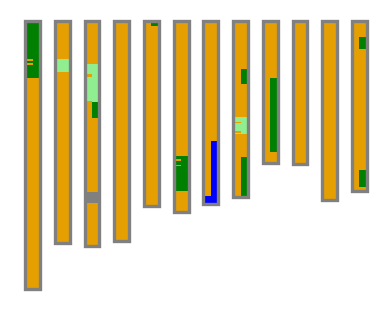

In [4]:
for i in range(21):
    line = f"Inov_{str(i+1).zfill(2)}"
    print(line)
    regions = Inov.params.value[line]
    hetero_regions = get_hetero_regions(line, regions, Inov_genotype)
    visualize_Inov_genotype(Inov_genotype, chr_ends, Inov.params.value[line], hetero_regions,
                            "#E69F00", Inov.params.value["colors"], dpi=80)

# Extract important HBs of Inov genotype

In [2]:
# extract best model and HB num
with open('../data/PART5_Select_HBs/Compare_models_by_all_RILs_selected_HBs.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

In [3]:
Inov_genotype = pd.read_csv("../data/PART6_validate_with_Inov_lines/Haplotype_Inov_LD90.csv")

for trait_name in ["LW_mean", "GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    model = trait_summary.sort_values(by="r", ascending=False).iloc[0, 1]
    
    # extract feature importances
    with open('../data/PART4_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary_all_HB = pickle.load(p)
    summary_all_HB = pd.DataFrame(summary_all_HB)
    
    path = "../data/PART6_Validate_with_Inov_lines/{}_{}_{}_Inov.csv".format(trait_name, model, HB_num)                
    imp = np.mean(summary_all_HB.loc[(summary_all_HB.iloc[:, 0] == trait_name) & (summary_all_HB.iloc[:, 2] == model), 6].values, axis=0)
    high_imp_index = np.sort(np.argsort(np.abs(imp))[::-1][:HB_num])
    Inov_genotype.loc[high_imp_index, :].to_csv(path, index=None)

# Inov accuracy by best model

LW_mean Enet 800
CV0
CV1
CV2
CV3
CV4
0.91638068678098


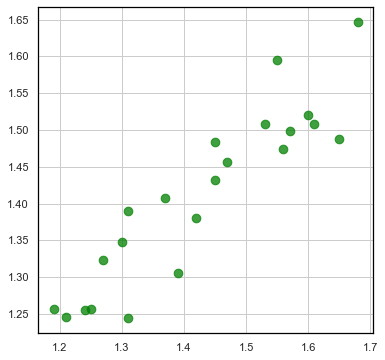

GN_mean Enet 900
CV0
CV1
CV2
CV3
CV4
0.9051660652234668


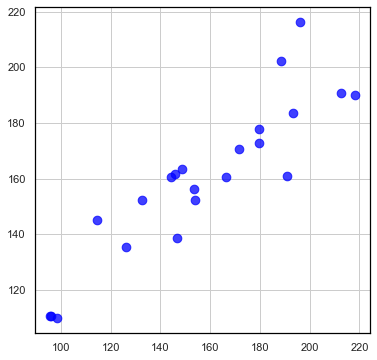

PN_mean Enet 1000
CV0
CV1
CV2
CV3
CV4
0.8735587168195916


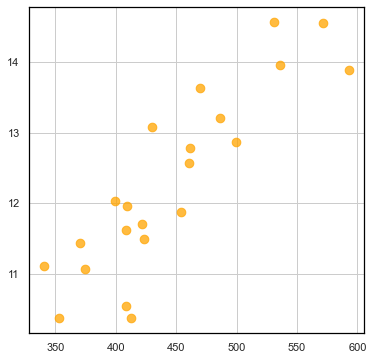

Area.size.AS..mm2. Enet 600
CV0
CV1
CV2
CV3
CV4
0.6571750121368709


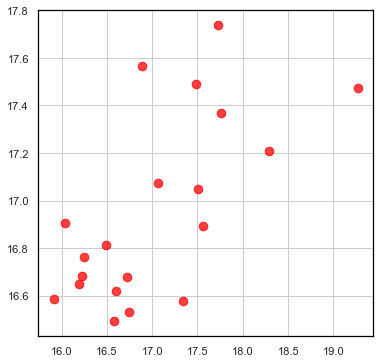

In [7]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV=5

Inov_phenotypes = pd.read_csv("../data/PART6_validate_with_Inov_lines/Inov_observed_phenotype_2020.csv", index_col=0)

for i in [["LW_mean", "green"], ["GN_mean", "blue"], ["PN_mean", "orange"], ["Area.size.AS..mm2.", "red"]]:
    trait_name = i[0]
    color = i[1]
    # select best HB_num and model
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    trait_summary = trait_summary.groupby(["HB_num", "model"]).mean().reset_index()
    HB_num = trait_summary.sort_values(by="r", ascending=False).iloc[0, 0]
    model = trait_summary.sort_values(by="r", ascending=False).iloc[0, 1]
    print(trait_name, model, HB_num)
    # make training dataset
    genotype = "../data/PART5_Select_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)    
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
    # make Inov genotype dataset
    Inov_genotype = pd.read_csv("../data/PART6_Validate_with_Inov_lines/{}_{}_{}_Inov.csv".format(trait_name, model, HB_num)).iloc[:, 3:]
    Inov_genotype["Hitomebore"] = 0
    Inov_genotype = Inov_genotype.fillna(1).T
    
    Inov_preds = []
    for i in range(CV):
        print("CV{}".format(i))
        # parameters
        if model != 'GBLUP':
            params = pd.read_csv("../data/PART5_Select_HBs/{}_selected_HBs_{}_params.csv".format(model, trait_name), index_col=0)
            params.columns = ["trait", "HB_num", "CV", "params"]
            params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i) & (params["HB_num"] == HB_num), "params"].values[0])
        tmp_train_data = train_data[i]
        X_train = tmp_train_data[0].fillna(1)
        y_train = tmp_train_data[1]
        # train model
        clf = ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        # predicted values of test phenotype
        Inov_pred = clf.predict(Inov_genotype)
        Inov_preds.append(Inov_pred)
    Inov_preds = np.mean(Inov_preds, axis=0)
    Inov_obs = Inov_phenotypes[trait_name].values
    scatter_data = pd.DataFrame({"y":Inov_obs, "pred":Inov_preds, "line":Inov_phenotypes.index.values})
    scatter_data = scatter_data.dropna()
    print(np.corrcoef([scatter_data.y, scatter_data.pred])[0,1])
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(data=scatter_data, x="y", y="pred", s=75, color=color, linewidth=1, alpha=0.75)
    min_val = min(min(Inov_obs), min(Inov_preds))
    max_val = max(max(Inov_obs), max(Inov_preds))
#     if trait_name != "PN_mean":
#         plt.plot([min_val, max_val], [min_val, max_val], ls="--", c=".3")
    for sp in ["top", "left", "right", "bottom"]:
        ax.spines[sp].set_color('black')
    plt.show()